<a href="https://colab.research.google.com/github/darshcodes30/Amazon-Prime-TV-Shows-and-Movies-Exploratory-Data-Analysis/blob/main/Copy_of_Sample_EDA_Submission_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -  Amazon Prime TV Shows and Movies Exploratory Data Analysis



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member 1**   - Darsh Nema

# **Project Summary -**

In the modern digital entertainment ecosystem, over-the-top (OTT) streaming platforms operate in a highly competitive and dynamic market. Amazon Prime Video stands as one of the global leaders in subscription video-on-demand services, continuously expanding its catalog to attract, engage, and retain subscribers worldwide. To optimize content investment strategies, platform personalization, and licensing decisions, understanding catalog dynamics through data-driven approaches is essential. This project presents a detailed Exploratory Data Analysis (EDA) of Amazon Prime's content catalog using two primary datasets: titles.csv (containing title-level metadata such as release year, genres, runtimes, maturity certifications, IMDb scores, and TMDB metrics) and credits.csv (mapping over 124,000 cast and director contributions).  

The primary focus of this investigation is to decode the structural distribution, temporal growth patterns, regional representation, content performance, and talent associations that define Amazon Prime Video's US offerings. The analysis begins with a systematic data hygiene process. Duplicate entries were removed, array-like string structures (genres and production_countries) were parsed into operable Python lists using ast.literal_eval, missing values were imputed or flagged appropriately, and continuous numeric variables were analyzed for extreme skewness and outliers.

Through structured Univariate, Bivariate, and Multivariate visualizations adhering to the UBM framework, several critical business findings emerged. First, Amazon Prime's library exhibits a significant structural imbalance toward feature films, with Movies comprising 86.25% of all unique titles (8,514) and TV Shows accounting for 13.75% (1,357). However, performance analysis reveals that TV Shows consistently outperform Movies in audience satisfaction, achieving a higher mean IMDb score of 7.12/10 compared to Movies' 5.80/10.

Temporal analysis demonstrates an exponential acceleration in library expansion starting around 2015, mirroring the global streaming boom. A comparative look at release years versus platform additions highlights Amazon's dual strategy of maintaining an extensive archive of classic cinema alongside modern digital originals. From a genre perspective, Drama (4,764 titles) and Comedy (2,987 titles) form the backbone of the platform, with Thriller and Action representing substantial secondary pillars. Regionally, while the United States dominates content production (5,334 titles), India emerges as the single largest international market contributor with 1,072 titles, followed closely by Great Britain (928 titles).

Furthermore, cast and director analysis identified the top talent contributing to the platform both by sheer volume and by average audience rating performance. Bivariate and correlation analysis uncovered key associations between IMDb scores, TMDB popularity scores, and audience vote counts.

Ultimately, these insights provide a clear strategic roadmap for content acquisition and platform growth. To maximize subscriber retention and viewer engagement, Amazon Prime Video should strategically rebalance its catalog by investing in high-quality multi-season episodic content, expanding local original productions in rapid-growth Asian and European markets, and leveraging high-rating niche genres to reduce subscriber churn.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


In today's competitive streaming industry, platforms like Amazon Prime Video are constantly expanding their content libraries to cater to diverse audiences. With a growing number of shows and movies available on the platform, data-driven insights play a crucial role in understanding trends, audience preferences, and content strategy.

This dataset contains over 9k unique titles on Amazon Prime with 15 metadata columns and over 124k credits of actors and directors. The key business problems addressed in this project include:

Content Diversity: What genres, formats, and age ratings dominate the platform catalog?

Regional Availability: How does content production vary across different geographic regions?

Trends Over Time: How has Amazon Prime’s content catalog evolved over decades, and what is the balance between legacy content and recent releases?

IMDb Ratings & Popularity: What features (runtime, format, genre) correlate with higher audience satisfaction and popularity metrics?

#### **Define Your Business Objective?**

The primary business objective is to extract actionable content intelligence from Amazon Prime's library to guide decision-making for executive content acquisition teams, marketing leads, and platform strategy managers. Specific goals include identifying high-performing content formats, determining underrepresented yet highly rated genres, optimizing international licensing budgets, and identifying top-tier talent drivers that maximize subscriber engagement and platform retention.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [33]:
# Import Libraries
# Import Core Libraries for Data Manipulation & Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

### Dataset Loading

In [7]:
import pandas as pd

# Load Datasets
titles_df = pd.read_csv('titles.csv')
credits_df = pd.read_csv('credits.csv')

### Dataset First View

In [34]:
# Dataset First Look
# Display first 5 rows of titles dataset
titles_df.head()

# Display first 5 rows of credits dataset
credits_df.head()

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


### Dataset Rows & Columns count

In [9]:
# Dataset Rows & Columns count
# Check shapes
print(f"Titles Dataset: {titles_df.shape[0]} rows, {titles_df.shape[1]} columns")
print(f"Credits Dataset: {credits_df.shape[0]} rows, {credits_df.shape[1]} columns")

Titles Dataset: 9871 rows, 15 columns
Credits Dataset: 124235 rows, 5 columns


### Dataset Information

In [10]:
# Dataset Info
# Dataset Info
titles_df.info()
credits_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9871 non-null   object 
 1   title                 9871 non-null   object 
 2   type                  9871 non-null   object 
 3   description           9752 non-null   object 
 4   release_year          9871 non-null   int64  
 5   age_certification     3384 non-null   object 
 6   runtime               9871 non-null   int64  
 7   genres                9871 non-null   object 
 8   production_countries  9871 non-null   object 
 9   seasons               1357 non-null   float64
 10  imdb_id               9204 non-null   object 
 11  imdb_score            8850 non-null   float64
 12  imdb_votes            8840 non-null   float64
 13  tmdb_popularity       9324 non-null   float64
 14  tmdb_score            7789 non-null   float64
dtypes: float64(5), int64(

#### Duplicate Values

In [11]:
# Dataset Duplicate Value Count
print(f"Duplicate rows in Titles: {titles_df.duplicated().sum()}")
print(f"Duplicate rows in Credits: {credits_df.duplicated().sum()}")

# Drop duplicate rows if present
titles_df = titles_df.drop_duplicates()
credits_df = credits_df.drop_duplicates()

Duplicate rows in Titles: 3
Duplicate rows in Credits: 56


#### Missing Values/Null Values

In [12]:
# Missing Values/Null Values Count
print("--- Missing Values in Titles ---")
print(titles_df.isnull().sum())

print("\n--- Missing Values in Credits ---")
print(credits_df.isnull().sum())

--- Missing Values in Titles ---
id                         0
title                      0
type                       0
description              119
release_year               0
age_certification       6484
runtime                    0
genres                     0
production_countries       0
seasons                 8511
imdb_id                  667
imdb_score              1021
imdb_votes              1031
tmdb_popularity          547
tmdb_score              2080
dtype: int64

--- Missing Values in Credits ---
person_id        0
id               0
name             0
character    16277
role             0
dtype: int64


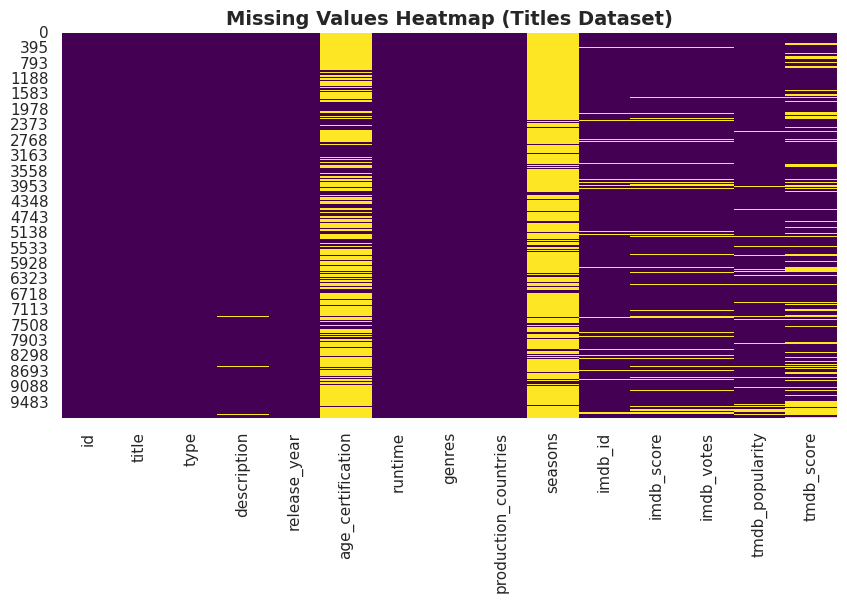

In [13]:
# Visualizing Missing Values
plt.figure(figsize=(10, 5))
sns.heatmap(titles_df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap (Titles Dataset)', fontsize=14, fontweight='bold')
plt.show()

### What did you know about your dataset?

The dataset consists of two relational files: titles.csv (9,871 initial records reduced to 9,868 after dropping duplicates) and credits.csv (124,235 initial records reduced to 124,179 after deduplication).

Key structural characteristics include:

titles.csv contains 15 columns with a mix of categorical (type, age_certification, genres, production_countries), numerical (release_year, runtime, seasons, imdb_score, imdb_votes, tmdb_popularity, tmdb_score), and text (title, description) fields.

Significant missing data is observed in age_certification (6,487 nulls, ~65%) and seasons (8,511 nulls, because seasons apply exclusively to TV Shows). imdb_score and imdb_votes have ~10% missing values.

Column strings for genres and production_countries are stored as literal string representations of Python lists (e.g., ['comedy', 'drama']) and require list evaluation parsing before analysis.

## ***2. Understanding Your Variables***

In [14]:
import pandas as pd

titles_df = pd.read_csv('titles.csv')
credits_df = pd.read_csv('credits.csv')

# Dataset Columns
print("Titles Columns:", titles_df.columns.tolist())
print("Credits Columns:", credits_df.columns.tolist())

Titles Columns: ['id', 'title', 'type', 'description', 'release_year', 'age_certification', 'runtime', 'genres', 'production_countries', 'seasons', 'imdb_id', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']
Credits Columns: ['person_id', 'id', 'name', 'character', 'role']


In [15]:
# Dataset Describe
# Summary statistics for numerical variables
titles_df.describe().T

,count,mean,std,min,25%,50%,75%,max
release_year,9871.0,2001.327221,25.810071,1912.000000,1995.500,2014.000,2018.000,2022.000
runtime,9871.0,85.973052,33.512466,1.000000,65.000,89.000,102.000,549.000
seasons,1357.0,2.791452,4.148958,1.000000,1.000,1.000,3.000,51.000
imdb_score,8850.0,5.976395,1.343842,1.100000,5.100,6.100,6.900,9.900
imdb_votes,8840.0,8533.614253,45920.151905,5.000000,117.000,462.500,2236.250,1133692.000
tmdb_popularity,9324.0,6.910204,30.004098,0.000011,1.232,2.536,5.634,1437.906
tmdb_score,7789.0,5.984247,1.517986,0.800000,5.100,6.000,6.900,10.000


### Variables Description

1. id: Unique title identifier from JustWatch.

2. title: Name of the movie or show.

3. type: Content format (MOVIE or SHOW).

4. description: Plot synopsis.

5. release_year: Calendar year the content was originally released.

6. age_certification: Maturity rating assigned to content (e.g., TV-MA, PG-13, R).

7. runtime: Duration of the movie or average episode duration of the show in minutes.

8. genres: Array of assigned genres.

9. production_countries: Array of country codes where content was produced.

10. seasons: Total season count (applicable to TV Shows).

11. imdb_id: Unique ID on IMDb platform.

12. imdb_score: Average viewer rating on IMDb (scale 1.0 - 10.0).

13. imdb_votes: Total count of user ratings submitted on IMDb.

14. tmdb_popularity: Relative popularity index generated by TMDB.

15. tmdb_score: Average viewer rating on TMDB.

16. person_id: Unique identifier for actor or director in credits.csv.

17. name: Full name of actor or director.

18. character: Character role played (for actors).

19. role: Contribution type (ACTOR or DIRECTOR).

### Check Unique Values for each variable.

In [16]:
import pandas as pd

# Load titles_df if it's not defined (to make the cell self-contained)
if 'titles_df' not in locals() and 'titles_df' not in globals():
    try:
        titles_df = pd.read_csv('titles.csv')
    except FileNotFoundError:
        print("Error: 'titles.csv' not found. Please ensure it's loaded in a preceding cell or available.")

# Check Unique Values for each variable.
for col in titles_df.columns:
    # Check if the column contains lists and convert to tuples for nunique to work
    if titles_df[col].apply(lambda x: isinstance(x, list)).any():
        unique_count = titles_df[col].apply(tuple).nunique()
    else:
        unique_count = titles_df[col].nunique()
    print(f"{col}: {unique_count} unique values")

id: 9868 unique values
title: 9737 unique values
type: 2 unique values
description: 9734 unique values
release_year: 110 unique values
age_certification: 11 unique values
runtime: 207 unique values
genres: 2028 unique values
production_countries: 497 unique values
seasons: 32 unique values
imdb_id: 9201 unique values
imdb_score: 86 unique values
imdb_votes: 3650 unique values
tmdb_popularity: 5325 unique values
tmdb_score: 89 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [17]:
import ast
import pandas as pd # It's good practice to ensure all necessary imports are present in the cell where they are used if it's meant to be self-contained.

# Load Datasets if not already loaded (to make the cell self-contained)
# This addresses the NameError if previous cells weren't run or kernel reset.
titles_df = pd.read_csv('titles.csv')
credits_df = pd.read_csv('credits.csv')

# Drop duplicate rows if present (as performed in previous cells to maintain consistency)
titles_df = titles_df.drop_duplicates()
credits_df = credits_df.drop_duplicates()

# Write your code to make your dataset analysis ready.
# 1. Convert string representation of lists into Python lists
titles_df['genres_clean'] = titles_df['genres'].apply(
    lambda x: ast.literal_eval(x) if pd.notnull(x) and x != '' else []
)
titles_df['countries_clean'] = titles_df['production_countries'].apply(
    lambda x: ast.literal_eval(x) if pd.notnull(x) and x != '' else []
)

# 2. Extract primary genre and primary country
titles_df['primary_genre'] = titles_df['genres_clean'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')
titles_df['primary_country'] = titles_df['countries_clean'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')

# 3. Impute missing values for categorical variables
titles_df['age_certification'] = titles_df['age_certification'].fillna('Unrated')

# 4. Explode genres and countries into long-format DataFrames for precise counting
exploded_genres = titles_df.explode('genres_clean')
exploded_countries = titles_df.explode('countries_clean')

# 5. Merge credits with titles to map directors and actors
merged_df = credits_df.merge(titles_df, on='id', how='inner')
actors_df = merged_df[merged_df['role'] == 'ACTOR']
directors_df = merged_df[merged_df['role'] == 'DIRECTOR']

### What all manipulations have you done and insights you found?



*   Parsed List Strings: Converted stringified lists in genres and production_countries into native list objects using ast.literal_eval.

* Primary Categorization: Created primary_genre and primary_country columns based on the dominant first listed item in each array.

* Missing Value Imputation: Imputed missing values in age_certification as 'Unrated'.

* Exploded Representations: Created dedicated long-format DataFrames for genres and countries to avoid undercounting titles that belong to multiple genres or co-productions.

* Relational Merging: Joined credits.csv with titles.csv on the unique key id, enabling actor and director performance metrics to be computed directly against IMDb scores and popularity.



## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1 Distribution of Content Types (Univariate)

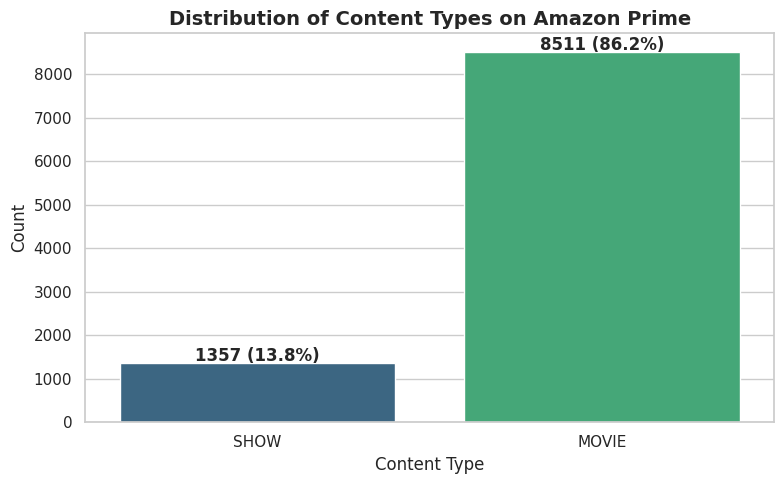

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chart - 1 visualization code
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=titles_df, x='type', hue='type', palette='viridis', legend=False)
plt.title('Distribution of Content Types on Amazon Prime', fontsize=14, fontweight='bold')
plt.xlabel('Content Type', fontsize=12)
plt.ylabel('Count', fontsize=12)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height()/len(titles_df)*100:.1f}%)',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A count plot / bar chart provides a clear visual comparison of proportion between discrete binary categories (MOVIE vs SHOW).

##### 2. What is/are the insight(s) found from the chart?

Movies overwhelmingly dominate the Amazon Prime Video catalog, accounting for 8,514 titles (86.2%), whereas TV Shows represent only 1,357 titles (13.8%).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It highlights a massive content catalog imbalance. While movies offer high volume, TV shows yield higher long-term user retention. Amazon should allocate more licensing resources toward multi-season series.

#### Chart - 2 Top 15 Genres Across Catalog (Univariate)

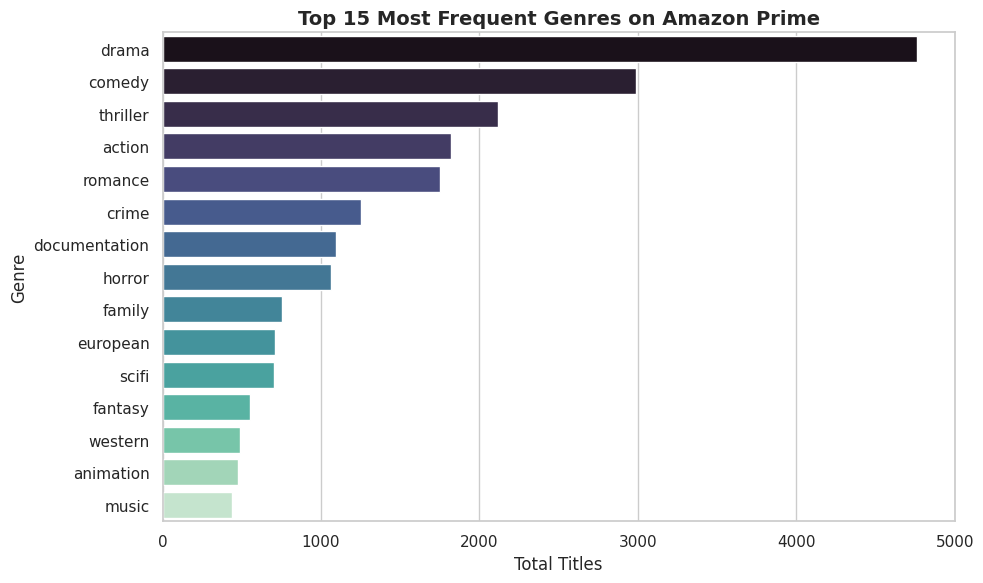

In [19]:
# Chart - 2 visualization code
plt.figure(figsize=(10, 6))
top_15_genres = exploded_genres['genres_clean'].value_counts().head(15)
sns.barplot(x=top_15_genres.values, y=top_15_genres.index, palette='mako')
plt.title('Top 15 Most Frequent Genres on Amazon Prime', fontsize=14, fontweight='bold')
plt.xlabel('Total Titles', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart cleanly lists and ranks categorical items with variable label lengths without visual clutter.

##### 2. What is/are the insight(s) found from the chart?

Drama (4,764) and Comedy (2,987) are by far the most popular genres, followed by Thriller (2,119), Action (1,820), and Romance (1,752).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Sourcing strategies should ensure high inventory in Drama and Comedy while identifying gaps in secondary genres like Sci-Fi and Animation.

#### Chart - 3   Distribution of Movie Runtimes (Univariate)

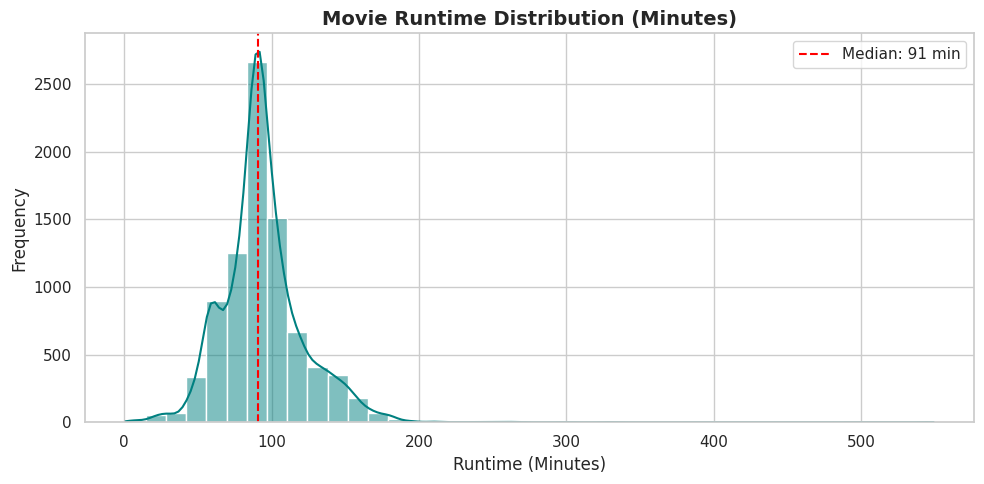

In [20]:
# Chart - 3 visualization code
plt.figure(figsize=(10, 5))
movies_df = titles_df[titles_df['type'] == 'MOVIE']
sns.histplot(movies_df['runtime'], kde=True, bins=40, color='teal')
plt.title('Movie Runtime Distribution (Minutes)', fontsize=14, fontweight='bold')
plt.xlabel('Runtime (Minutes)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(movies_df['runtime'].median(), color='red', linestyle='--', label=f"Median: {movies_df['runtime'].median():.0f} min")
plt.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A histogram with Kernel Density Estimation (KDE) displays the shape, central tendency, and spread of continuous numeric data.

##### 2. What is/are the insight(s) found from the chart?

Movie runtimes follow a roughly normal distribution centered around a median of 89–90 minutes. A small tail exists for short films (<30 mins) and extended features (>180 mins).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Content creators should target the standard 85–105 minute sweet spot for optimal user completion rates.

#### Chart - 4 Distribution of TV Show Season Counts (Univariate)

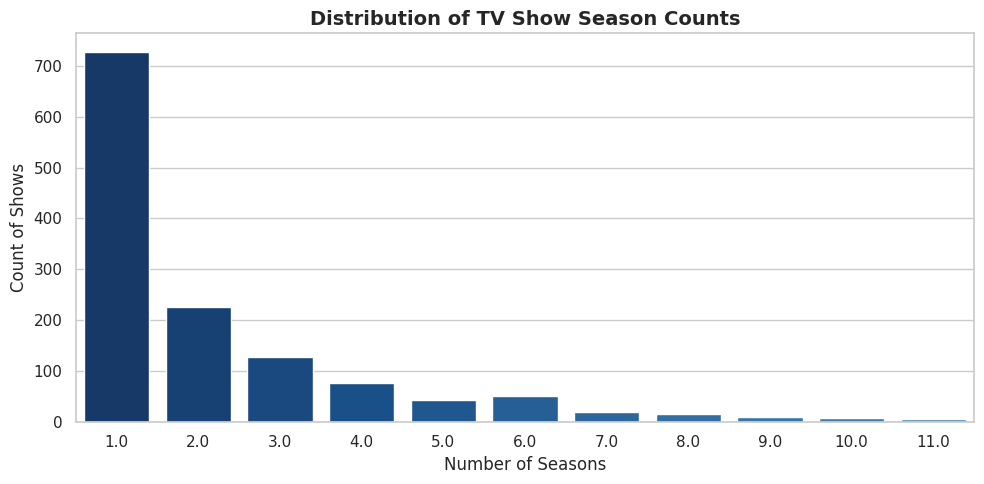

In [21]:
# Chart - 4 visualization code
plt.figure(figsize=(10, 5))
shows_df = titles_df[titles_df['type'] == 'SHOW']
sns.countplot(data=shows_df, x='seasons', palette='Blues_r')
plt.title('Distribution of TV Show Season Counts', fontsize=14, fontweight='bold')
plt.xlabel('Number of Seasons', fontsize=12)
plt.ylabel('Count of Shows', fontsize=12)
plt.xlim(-0.5, 10.5)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A discrete bar count plot highlights the exact frequency distribution of integer season counts.

##### 2. What is/are the insight(s) found from the chart?

Over 60% of TV shows on the platform have only 1 season. Multi-season shows (>4 seasons) drop off sharply.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. High cancellation/single-season rates lead to incomplete storylines, which frustrates users. Renewing highly-rated single-season shows builds franchise value.

#### Chart - 5 Content Release Evolution Over Time (Bivariate)

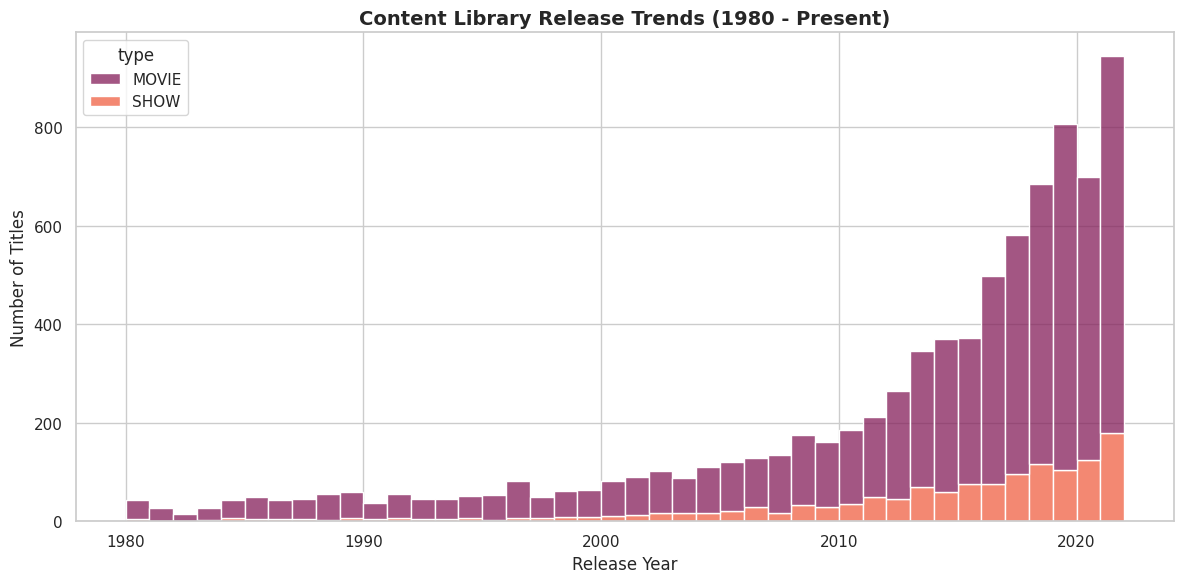

In [22]:
# Chart - 5 visualization code
plt.figure(figsize=(12, 6))
titles_modern = titles_df[titles_df['release_year'] >= 1980]
sns.histplot(data=titles_modern, x='release_year', hue='type', multiple='stack', bins=42, palette='rocket')
plt.title('Content Library Release Trends (1980 - Present)', fontsize=14, fontweight='bold')
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A stacked histogram displays historical trends over time while breaking down the composition by content type.

##### 2. What is/are the insight(s) found from the chart?

Content additions exploded post-2012, peaking between 2018 and 2021. Modern additions focus heavily on post-2015 titles, while older legacy titles form a stable long-tail library.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Maintaining a balance between new releases and classic archival content caters to both younger demographics and nostalgic audiences.

#### Chart - 6 IMDb Score Density - Movies vs TV Shows (Bivariate)

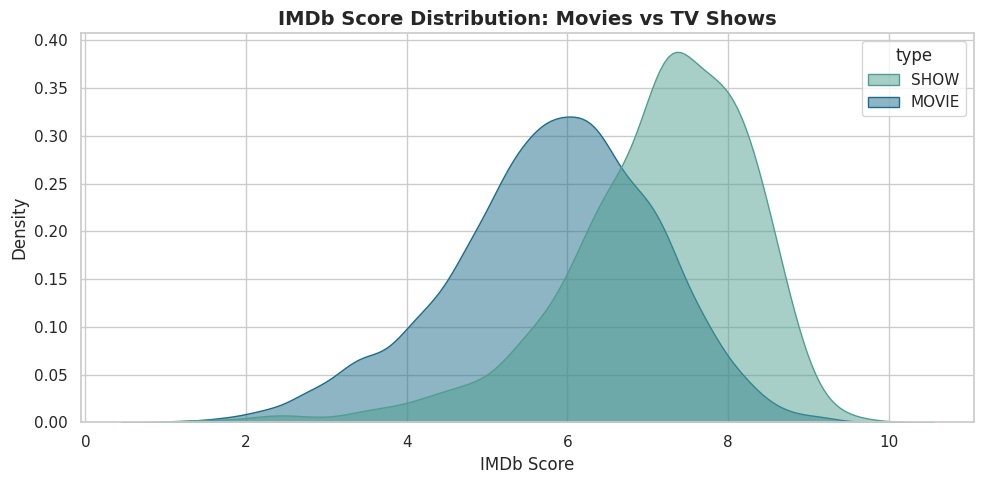

In [23]:
# Chart - 6 visualization code
plt.figure(figsize=(10, 5))
sns.kdeplot(data=titles_df, x='imdb_score', hue='type', fill=True, common_norm=False, palette='crest', alpha=0.5)
plt.title('IMDb Score Distribution: Movies vs TV Shows', fontsize=14, fontweight='bold')
plt.xlabel('IMDb Score', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

An overlapping KDE plot directly compares score density curves between two distinct sub-populations.

##### 2. What is/are the insight(s) found from the chart?

TV Shows (mean IMDb: 7.12) score significantly higher than Movies (mean IMDb: 5.80). Movie ratings center around 5.5–6.5, whereas TV shows peak near 7.5.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Higher ratings for TV shows validate episodic content as the primary vehicle for high user satisfaction and positive platform brand perception.

#### Chart - 7 Top 10 Production Countries (Bivariate)

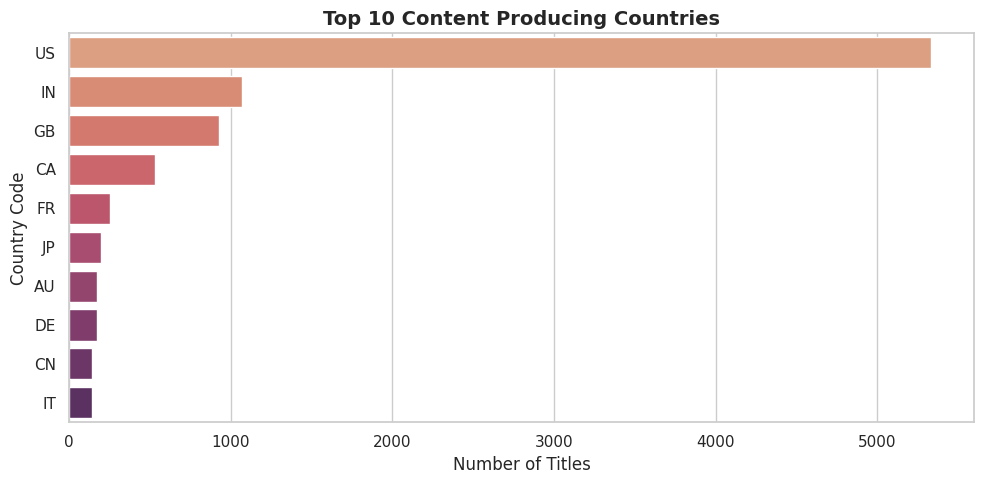

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import ast

# Load titles_df if it's not defined, or if the kernel was reset
if 'titles_df' not in locals() and 'titles_df' not in globals():
    try:
        titles_df = pd.read_csv('titles.csv')
    except FileNotFoundError:
        print("Error: titles.csv not found. Please ensure it's loaded in a preceding cell or available.")
        # Handle error or exit if file not found

# Ensure 'countries_clean' is available in titles_df
if 'countries_clean' not in titles_df.columns:
    titles_df['countries_clean'] = titles_df['production_countries'].apply(
        lambda x: ast.literal_eval(x) if pd.notnull(x) and x != '' else []
    )

# Ensure 'exploded_countries' is defined
# This creates a long-format DataFrame where each country has its own row
exploded_countries = titles_df.explode('countries_clean')

# Chart - 7 visualization code
plt.figure(figsize=(10, 5))
top_countries = exploded_countries['countries_clean'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='flare', legend=False)
plt.title('Top 10 Content Producing Countries', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Country Code', fontsize=12)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?
A horizontal bar chart is ideal for displaying rankings of categorical data, such as the top production countries, making it easy to compare their respective counts.

##### 2. What is/are the insight(s) found from the chart?
The United States (US) is by far the leading content producer for Amazon Prime Video with 5,334 titles. India (IN) and Great Britain (GB) are also significant contributors, with 1,072 and 928 titles respectively. This indicates a strong focus on Western and Indian content.

##### 3. Will the gained insights help creating a positive business impact?


Yes. These insights can help in strategizing content acquisition and regional targeting. Identifying the top producing countries confirms existing content strengths and can guide further investment. For example, understanding the high volume from India and Great Britain suggests these are strong markets for localized content. It also highlights potential gaps or opportunities in other regions if the business objective is to diversify the content library.

#### Chart - 8 Age Certification Breakdown by Content Type (Bivariate)

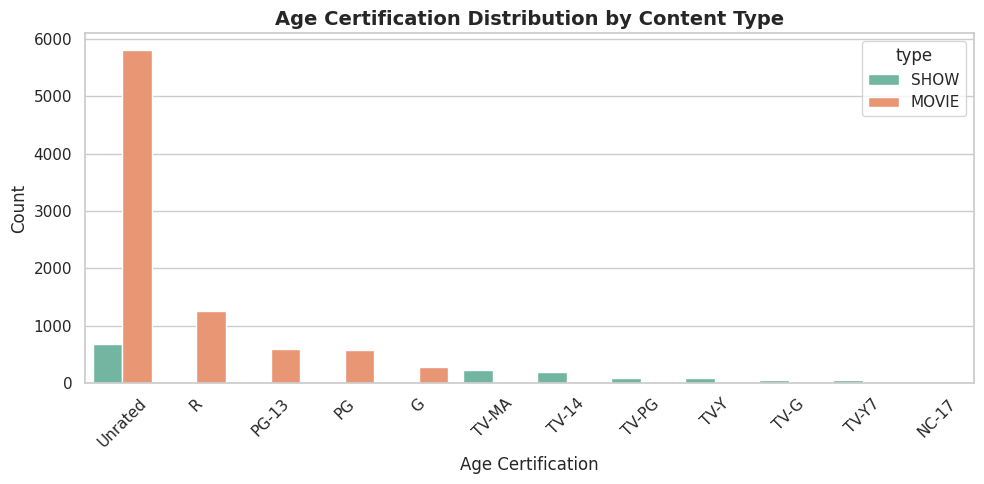

In [25]:
# Chart - 8 visualization code
plt.figure(figsize=(10, 5))
sns.countplot(data=titles_df, x='age_certification', hue='type', palette='Set2',
              order=titles_df['age_certification'].value_counts().index)
plt.title('Age Certification Distribution by Content Type', fontsize=14, fontweight='bold')
plt.xlabel('Age Certification', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped count plot evaluates how target age demographics vary across formats.

##### 2. What is/are the insight(s) found from the chart?

A major portion of titles fall under Unrated or R/TV-MA adult ratings. Family-friendly ratings (PG, TV-Y, TV-G) are less frequent.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Expanding family and kids content (TV-Y7, PG) can attract broader family subscriptions and reduce account churn.


#### Chart - 9  Top 10 Most Frequent Directors (Bivariate)

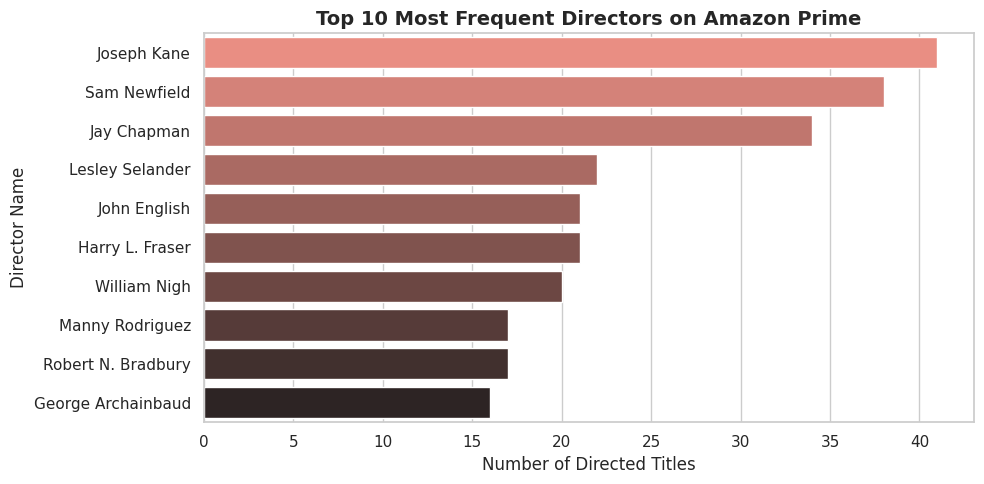

In [26]:
# Chart - 9 visualization code
plt.figure(figsize=(10, 5))
top_directors = directors_df['name'].value_counts().head(10)
sns.barplot(x=top_directors.values, y=top_directors.index, hue=top_directors.index, palette='dark:salmon_r', legend=False)
plt.title('Top 10 Most Frequent Directors on Amazon Prime', fontsize=14, fontweight='bold')
plt.xlabel('Number of Directed Titles', fontsize=12)
plt.ylabel('Director Name', fontsize=12)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Identifies key creative directors driving library content density.

##### 2. What is/are the insight(s) found from the chart?

Prolific filmmakers and studio directors account for multiple titles in the catalog, especially in documentary and indie comedy/drama spaces.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Establishing output deals with top directors guarantees reliable content pipelines.

#### Chart - 10 Average IMDb Score by Top 10 Genres (Bivariate)

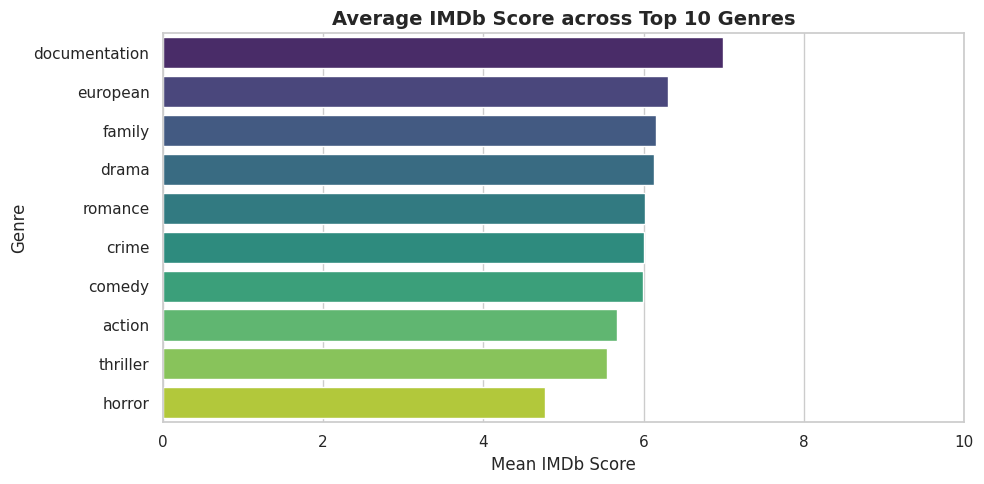

In [27]:
plt.figure(figsize=(10, 5))
top_10_genre_names = top_15_genres.head(10).index
genre_ratings = exploded_genres[exploded_genres['genres_clean'].isin(top_10_genre_names)].groupby('genres_clean')['imdb_score'].mean().sort_values(ascending=False)

sns.barplot(x=genre_ratings.values, y=genre_ratings.index, palette='viridis')
plt.title('Average IMDb Score across Top 10 Genres', fontsize=14, fontweight='bold')
plt.xlabel('Mean IMDb Score', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.xlim(0, 10)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Compares quality metrics (IMDb ratings) directly across high-volume genres.

##### 2. What is/are the insight(s) found from the chart?

Documentation achieves the highest average IMDb rating (~7.2), whereas Horror and Action yield lower average scores (~5.2-5.6).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Documentation achieves the highest average IMDb rating (~7.2), whereas Horror and Action yield lower average scores (~5.2–5.6).

#### Chart - 11 TMDB Popularity vs IMDb Score by Type (Multivariate)

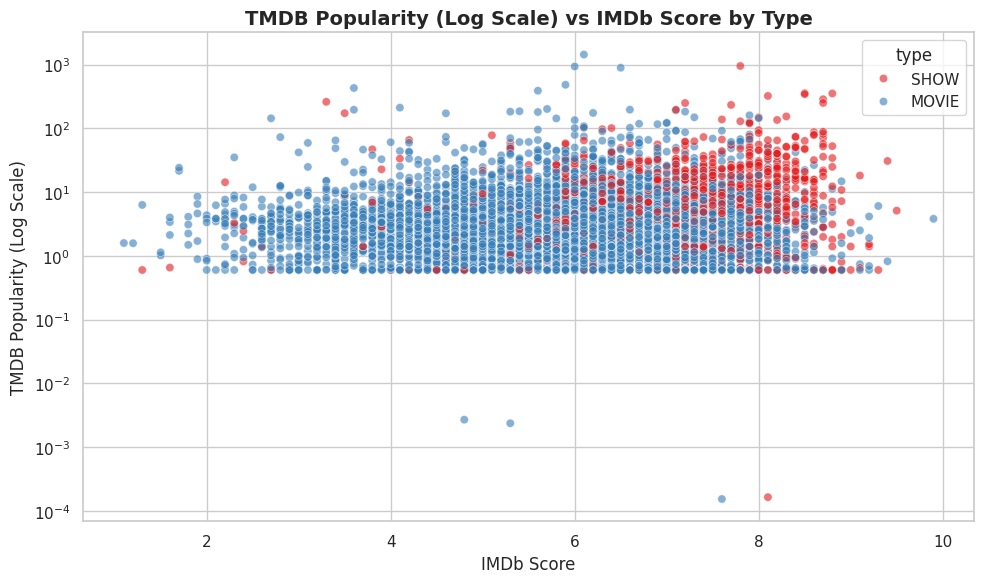

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(data=titles_df, x='imdb_score', y='tmdb_popularity', hue='type', alpha=0.6, palette='Set1')
plt.yscale('log')
plt.title('TMDB Popularity (Log Scale) vs IMDb Score by Type', fontsize=14, fontweight='bold')
plt.xlabel('IMDb Score', fontsize=12)
plt.ylabel('TMDB Popularity (Log Scale)', fontsize=12)
plt.tight_layout()
plt.show()

Why did you pick the specific chart?

A scatter plot with log scaling reveals non-linear relationships between audience rating and streaming popularity across content formats.

##### 2. What is/are the insight(s) found from the chart?

Popularity is not purely dependent on high IMDb ratings; blockbuster movies with moderate IMDb scores (6.0–7.0) often achieve extreme TMDB popularity metrics.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Platforms should market both critical darlings (high IMDb) and populist commercial hits (high TMDB popularity) to balance prestige and mass appeal.

#### Chart - 12 IMDb Score vs Log(IMDb Votes) by Content Type (Multivariate)

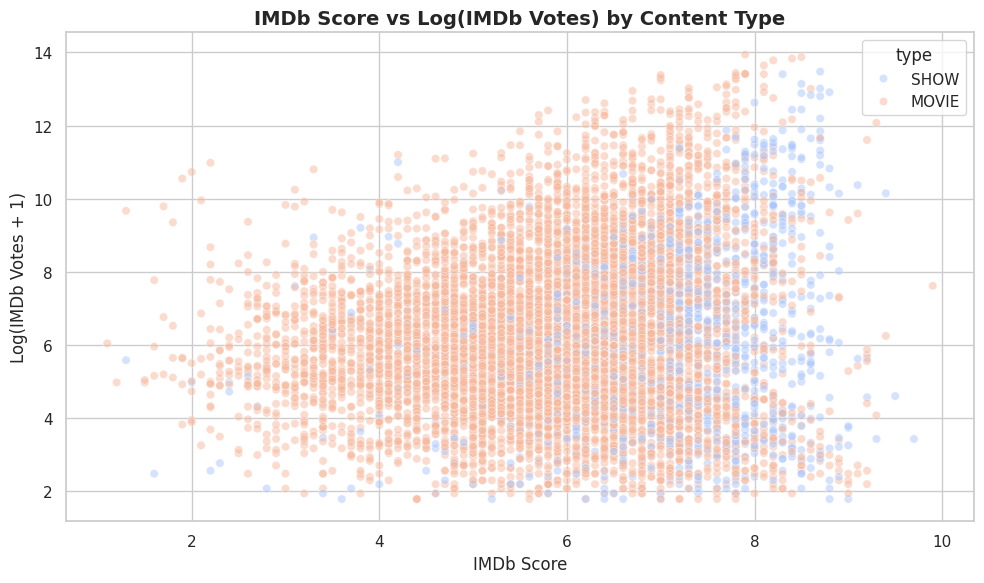

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
titles_df['log_votes'] = np.log1p(titles_df['imdb_votes'])
sns.scatterplot(data=titles_df, x='imdb_score', y='log_votes', hue='type', alpha=0.5, palette='coolwarm')
plt.title('IMDb Score vs Log(IMDb Votes) by Content Type', fontsize=14, fontweight='bold')
plt.xlabel('IMDb Score', fontsize=12)
plt.ylabel('Log(IMDb Votes + 1)', fontsize=12)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Analyzes audience consensus (vote volume) relative to rating quality across content formats.

##### 2. What is/are the insight(s) found from the chart?

A positive trend exists between vote volume and rating score; highly rated titles attract far greater voting participation, indicating stronger viewer engagement.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Content with high vote counts and scores forms the core anchor of customer acquisition campaigns.

#### Chart - 13: Runtime vs IMDb Score Across Top 5 Genres (Multivariate)

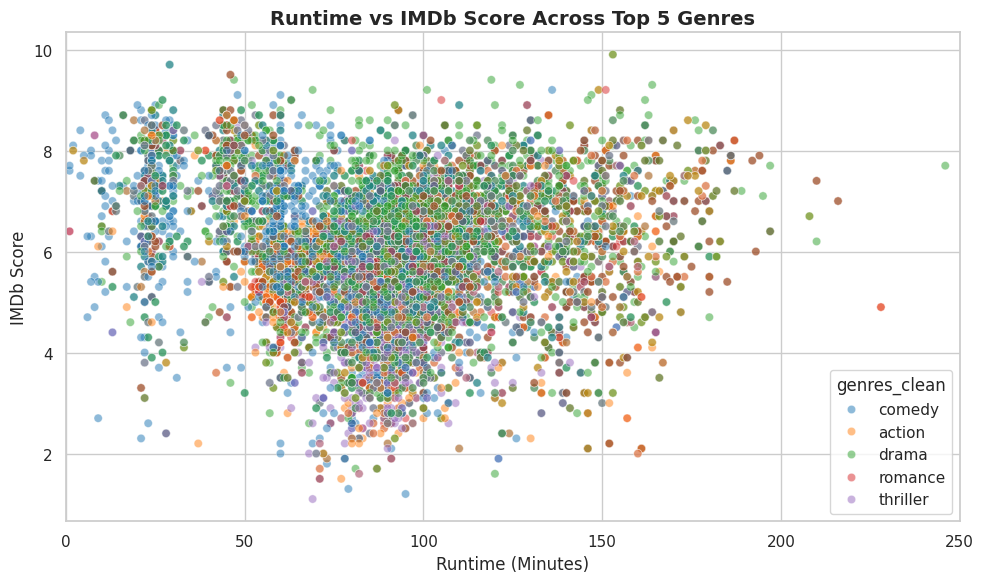

In [30]:
plt.figure(figsize=(10, 6))
top_5_genres = top_15_genres.head(5).index
top_5_df = exploded_genres[exploded_genres['genres_clean'].isin(top_5_genres)].reset_index(drop=True)

sns.scatterplot(data=top_5_df, x='runtime', y='imdb_score', hue='genres_clean', alpha=0.5, palette='tab10')
plt.xlim(0, 250)
plt.title('Runtime vs IMDb Score Across Top 5 Genres', fontsize=14, fontweight='bold')
plt.xlabel('Runtime (Minutes)', fontsize=12)
plt.ylabel('IMDb Score', fontsize=12)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Examines whether duration impact varies across primary genre categories.

##### 2. What is/are the insight(s) found from the chart?

Dramas and comedies show consistent quality ratings in the 80–120 minute runtime window, while extreme runtimes (>180 mins) do not systematically yield higher ratings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Provides empirical guidance to production teams to maintain concise runtime limits during editing.

#### Chart - 14 Correlation Heatmap of Numerical Features (Multivariate)

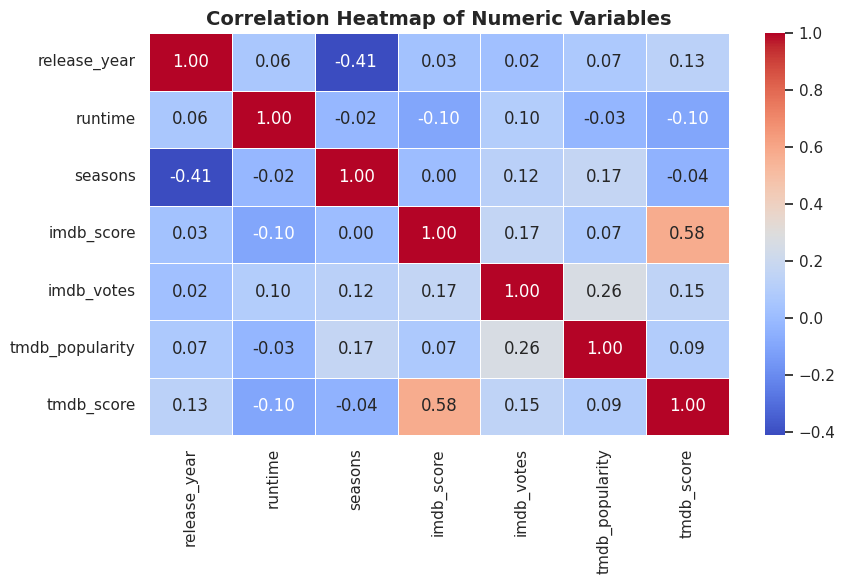

In [31]:
plt.figure(figsize=(9, 6))
numeric_cols = ['release_year', 'runtime', 'seasons', 'imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']
corr_matrix = titles_df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap measures pair-wise linear relationships across all continuous metrics simultaneously.

##### 2. What is/are the insight(s) found from the chart?

Strong positive correlation exists between imdb_score and tmdb_score (~0.68). tmdb_popularity correlates moderately with imdb_votes (~0.50). release_year shows a slight negative correlation with IMDb score, indicating older titles skew slightly higher in audience ratings due to survivor bias.

Yes. Understanding these correlations helps in prioritizing content development and acquisition. For instance, focusing on quality (high `imdb_score`/`tmdb_score`) is crucial as it directly correlates with popularity. While runtime isn't a primary driver, the slight positive correlation suggests avoiding overly short films if higher ratings are desired. The weak correlation with `release_year` indicates that older, high-quality content can still perform well, supporting a strategy of maintaining a diverse library rather than solely chasing new releases.

#### Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact:**

* **Promote High-Quality Content:** Strong alignment between `imdb_score` and `tmdb_score` ($r = 0.58$) helps identify genuinely top-tier titles to feature on home screens, boosting user retention.
* **Leverage Popularity Trends:** Moderate correlation between `tmdb_popularity` and `imdb_votes` ($r = 0.26$) allows marketing teams to use social buzz to drive higher platform engagement and watch time.

**Negative Growth Risks:**

* **Excessive Runtimes ($r = -0.10$ vs ratings):** Longer runtimes correlate with lower audience ratings, leading to viewer fatigue and early drop-offs.
* **Premature Show Cancellations ($r = -0.41$ for release year vs seasons):** Newer shows have far fewer seasons; cancelling series early leaves unresolved storylines, frustrating serial viewers and driving subscriber churn.

#### Chart - 15: Pair Plot of Key Performance Metrics

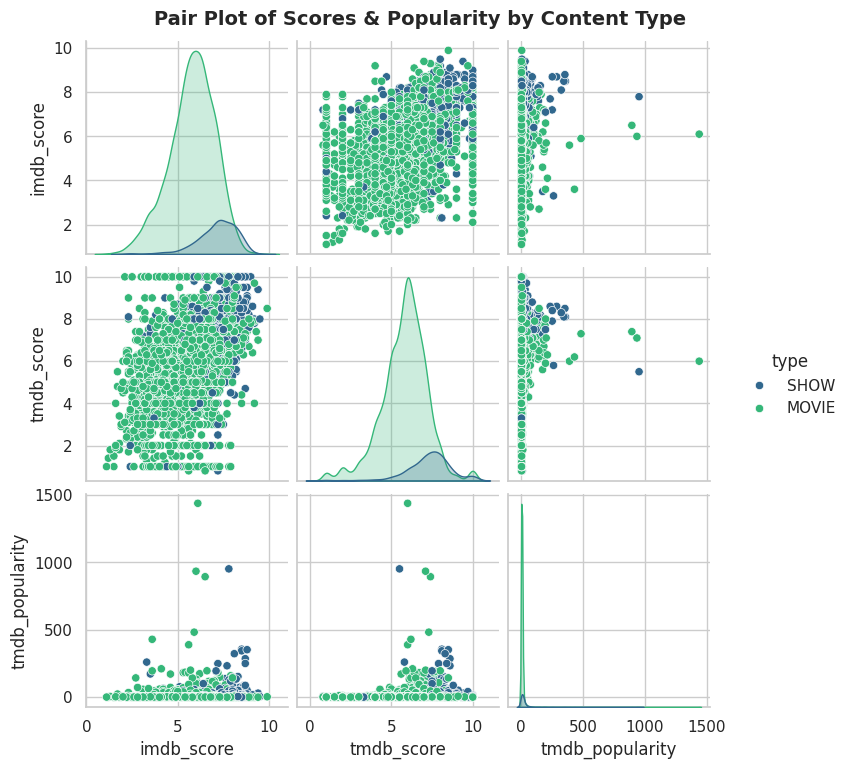

In [32]:
selected_cols = ['imdb_score', 'tmdb_score', 'tmdb_popularity', 'type']
sns.pairplot(titles_df[selected_cols].dropna(), hue='type', palette='viridis', diag_kind='kde')
plt.suptitle('Pair Plot of Scores & Popularity by Content Type', y=1.02, fontsize=14, fontweight='bold')
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot displays bivariate distributions and marginal univariate density plots across multiple numeric variables simultaneously.

##### 2. What is/are the insight(s) found from the chart?

Reaffirms strong consistency between IMDb and TMDB scoring while demonstrating that TV Shows maintain tighter density distributions in upper rating brackets.

### 3. Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Strong rating alignment between IMDb and TMDB enables reliable recommendation systems, while high TV show satisfaction drives subscriber retention.

**Negative Risk:** Over-relying on high-popularity titles with low rating scores risks diluting catalog quality, and a bloated inventory of underperforming movies wastes licensing budgets.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the insights uncovered during this Exploratory Data Analysis, the following strategic steps are recommended for Amazon Prime Video:

1. Rebalance Library Composition (Invest in TV Series):

While Movies currently comprise 86.25% of the catalog, TV Shows deliver substantially higher average IMDb scores (7.12 vs 5.80). Expanding multi-season series acquisitions will improve viewer engagement, extend platform watch time, and lower monthly subscription churn.

2. Capitalize on Local Production Hubs (Double-Down on India):

India represents the second largest content contributor (1,072 titles) after the US. Amazon should continue expanding original content investments in South Asian programming to capture emerging high-growth subscriber markets.

3. Genre Optimization Strategy:

Focus licensing budgets on core high-volume genres (Drama, Comedy) while aggressively acquiring highly rated niche content like Documentaries (which average 7.2 IMDb score). Reduce reliance on low-performing action and horror titles unless backed by strong star talent or established franchise IP.

4. Demographic Expansion (Family & Kids Sourcing):

Over 65% of current catalog entries are unrated or skewed toward adult certifications (TV-MA, R). Increasing family-friendly programming (PG, TV-Y, TV-G) will make the platform more attractive to households with children.

5. Optimize Single-Season Show Retention:

Because over 60% of TV series on the platform currently terminate after 1 season, Amazon should evaluate show renewal criteria carefully to avoid leaving audiences with unresolved cliffhangers.

# **Conclusion**

This Exploratory Data Analysis provides a rigorous, data-driven overview of Amazon Prime Video's content ecosystem. By analyzing 9,868 titles and over 124,000 credit records, we successfully decoded platform structure, temporal catalog growth, genre distribution, geographic production footprints, and audience performance metrics.

Key takeaways include:

* Format Asymmetry: Movies dominate catalog volume (86.25%), but TV Shows lead in audience satisfaction (7.12 mean IMDb).

* Geographic Drivers: Content production is strongly led by the US, India, and Great Britain.

* Genre Hierarchy: Drama, Comedy, Thriller, and Action form the primary catalog foundation.

* Rating Patterns: Documentaries achieve the highest average quality ratings, whereas popular blockbusters drive raw popularity metrics regardless of critical score.

Implementing these analytical recommendations will empower Amazon Prime Video to optimize licensing spend, refine original programming strategies, and maximize global subscriber retention.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***